In [26]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("All imports done")

All imports done


In [28]:

df = pd.read_csv(
    "silver_arimax_data.csv",
    parse_dates=["Date"],
    index_col="Date"
)


In [29]:
df.head()

,Silver Price,Interest Rate,Inflation Changes,Oil Price,DXY,GPRHT,SPX500
Date,,,,,,,
1975-01-01,4.15,7.50,0.39,11.16,95.61,83.86,76.98
1975-01-02,4.42,7.39,0.77,11.16,93.00,112.83,81.59
1975-01-03,4.28,7.73,0.38,11.16,94.82,81.50,83.36
1975-01-04,4.43,8.23,0.38,11.16,95.39,89.52,87.30
1975-01-05,4.53,8.06,0.57,11.16,94.63,91.75,91.15


In [30]:
df.columns = df.columns.str.replace(" ", "_")

In [31]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 612 entries, 1975-01-01 to 2025-01-12
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Silver_Price       612 non-null    float64
 1   Interest_Rate      612 non-null    float64
 2   Inflation_Changes  612 non-null    float64
 3   Oil_Price          612 non-null    float64
 4   DXY                612 non-null    float64
 5   GPRHT              612 non-null    float64
 6   SPX500             612 non-null    float64
dtypes: float64(7)
memory usage: 38.2 KB


<Axes: xlabel='Date'>

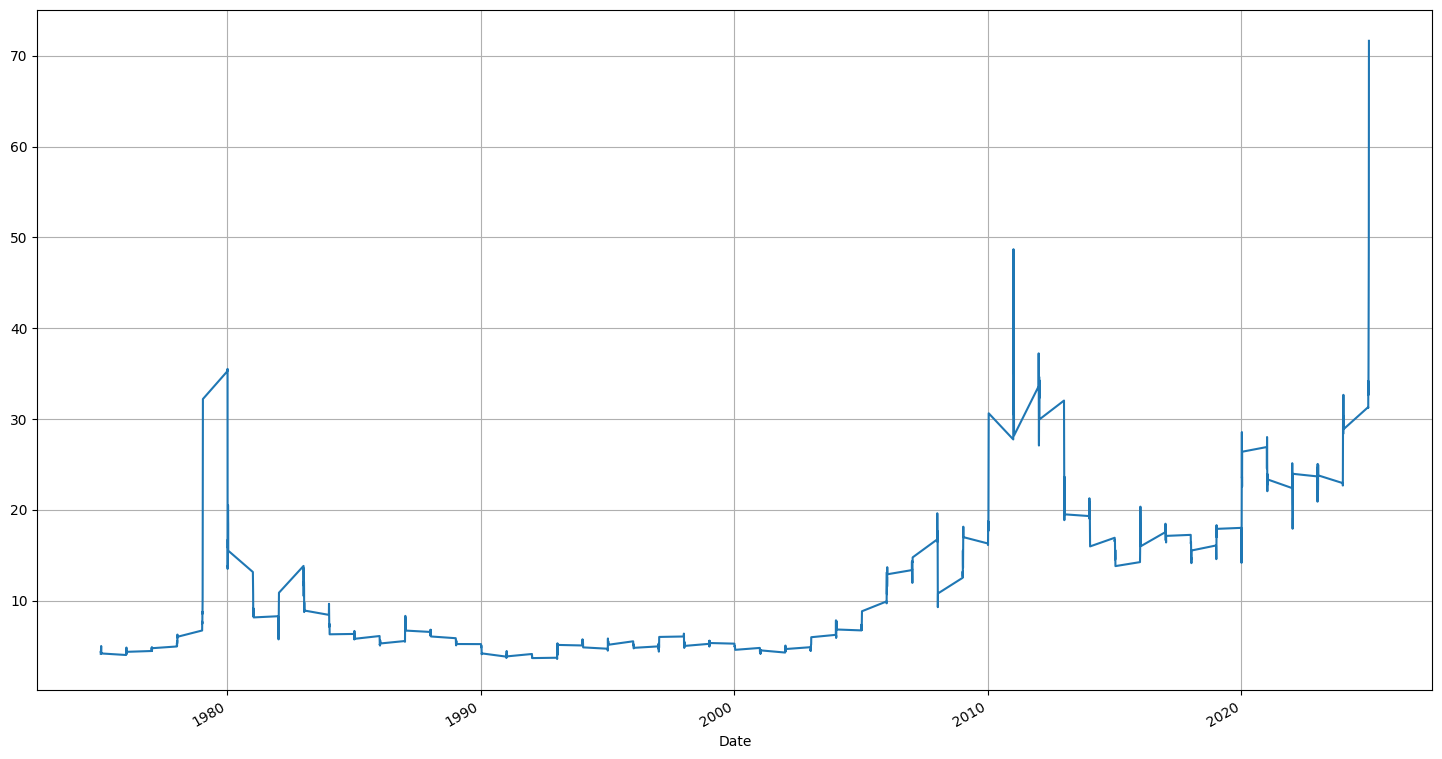

In [33]:
df["Silver_Price"].plot(figsize=(18,10), grid=True)

In [35]:

# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["Silver_Price"].dropna())
print(f"Silver_Price_lambda: {lambda_val:.4f}")

Silver_Price_lambda: -0.4471


<Axes: xlabel='Date'>

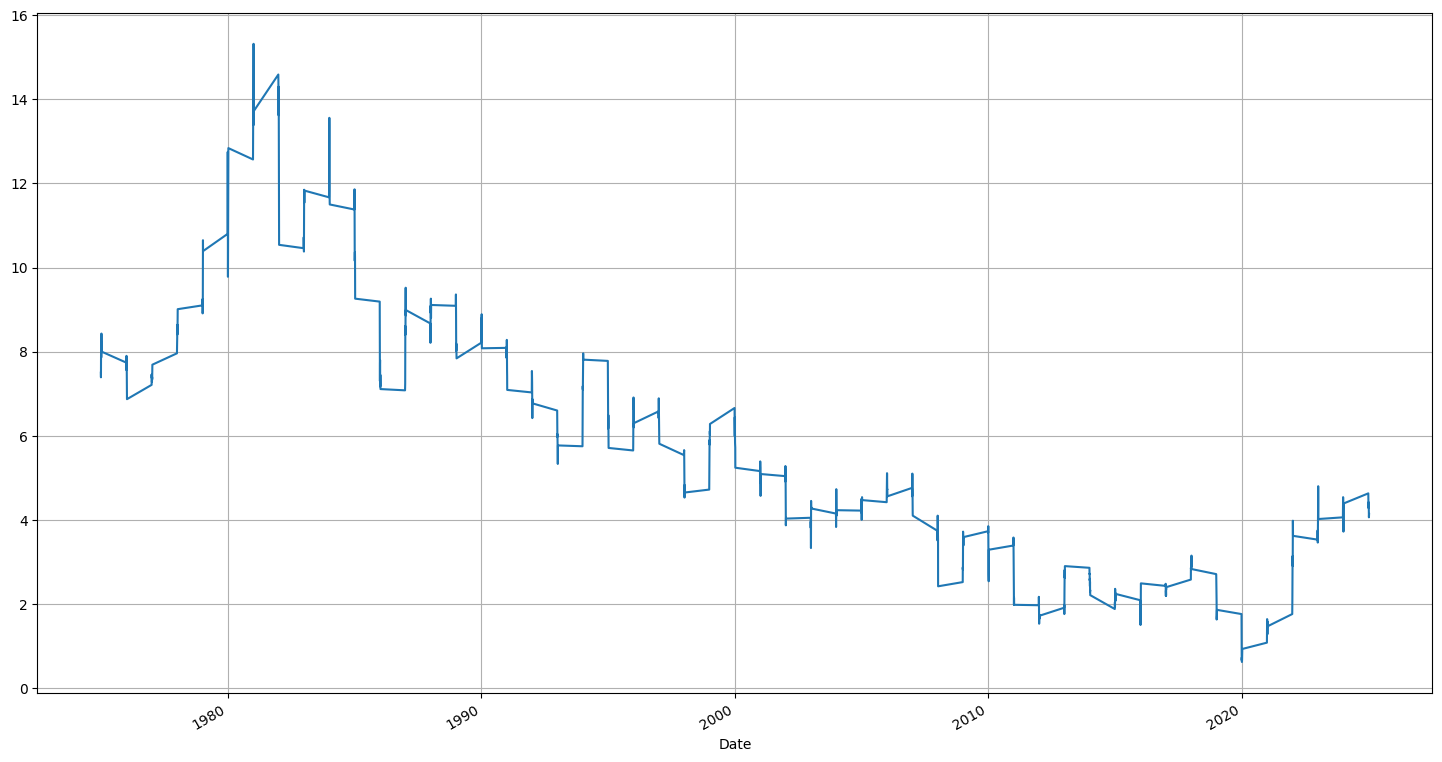

In [36]:
df["Interest_Rate"].plot(figsize=(18,10), grid=True)

In [37]:
transformed, lambda_val = stats.boxcox(df["Interest_Rate"].dropna())
print(f"Interest_Rate_lambda: {lambda_val:.4f}")

Interest_Rate_lambda: 0.3891


<Axes: xlabel='Date'>

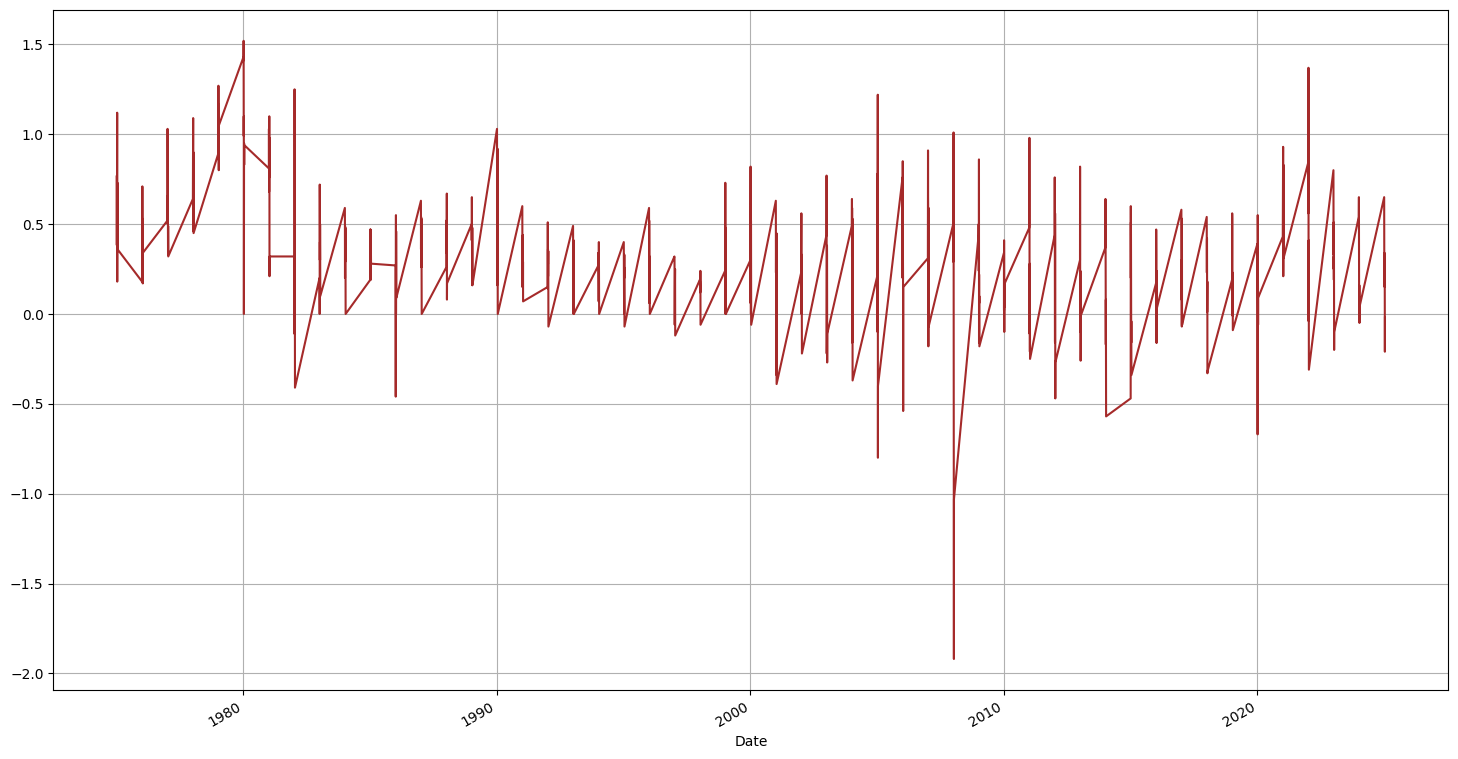

In [38]:
df["Inflation_Changes"].plot(figsize=(18,10), grid=True, color="brown")

<Axes: xlabel='Date'>

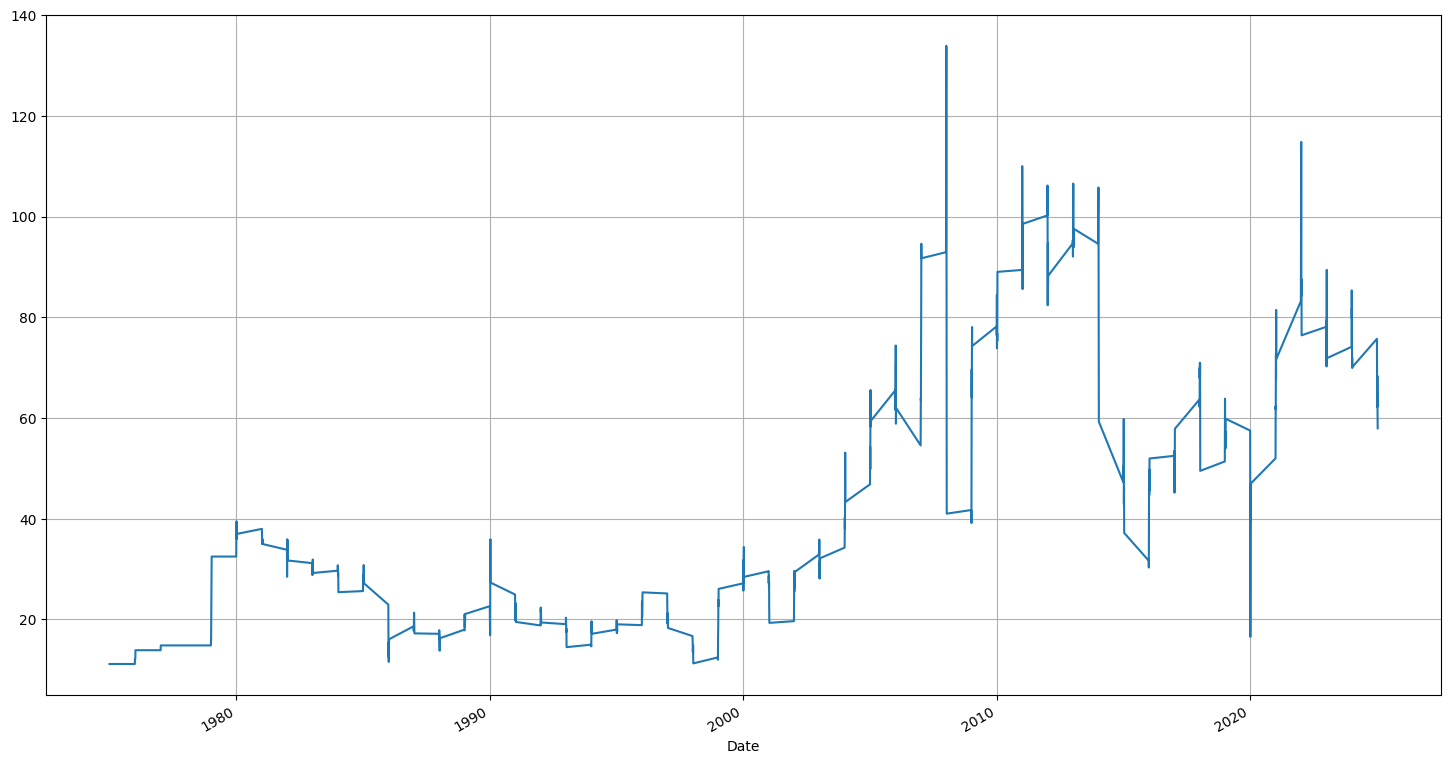

In [39]:
df["Oil_Price"].plot(figsize=(18,10), grid=True)

In [40]:
transformed, lambda_val = stats.boxcox(df["Oil_Price"].dropna())
print(f"Oil_Price_lambda: {lambda_val:.4f}")

Oil_Price_lambda: -0.1171


<Axes: title={'center': 'Oil_Price_Log'}, xlabel='Date'>

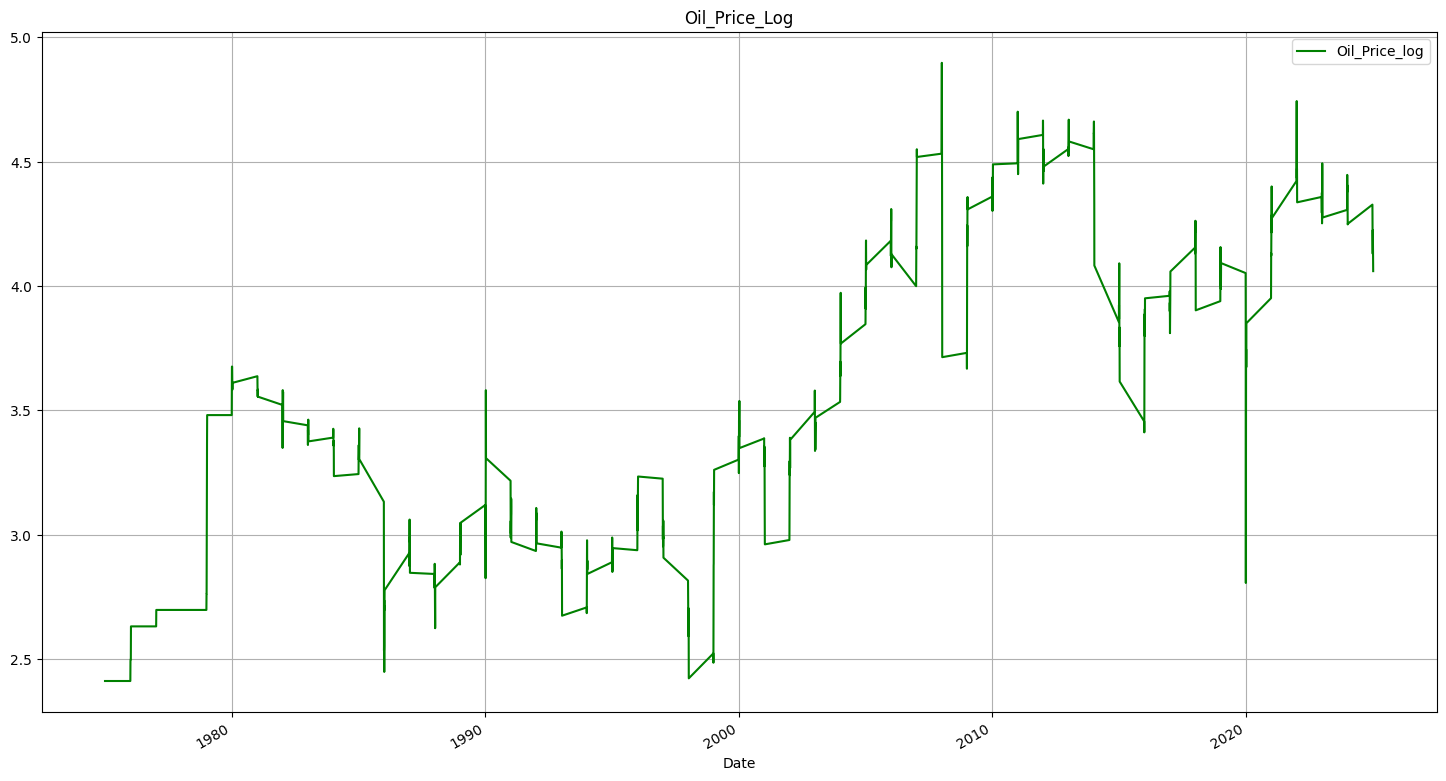

In [41]:
# Log transform
df["Oil_Price_log"] = np.log(df["Oil_Price"])


df[["Oil_Price_log"]].plot(figsize=(18,10), title="Oil_Price_Log", grid=True, color="green")

<Axes: xlabel='Date'>

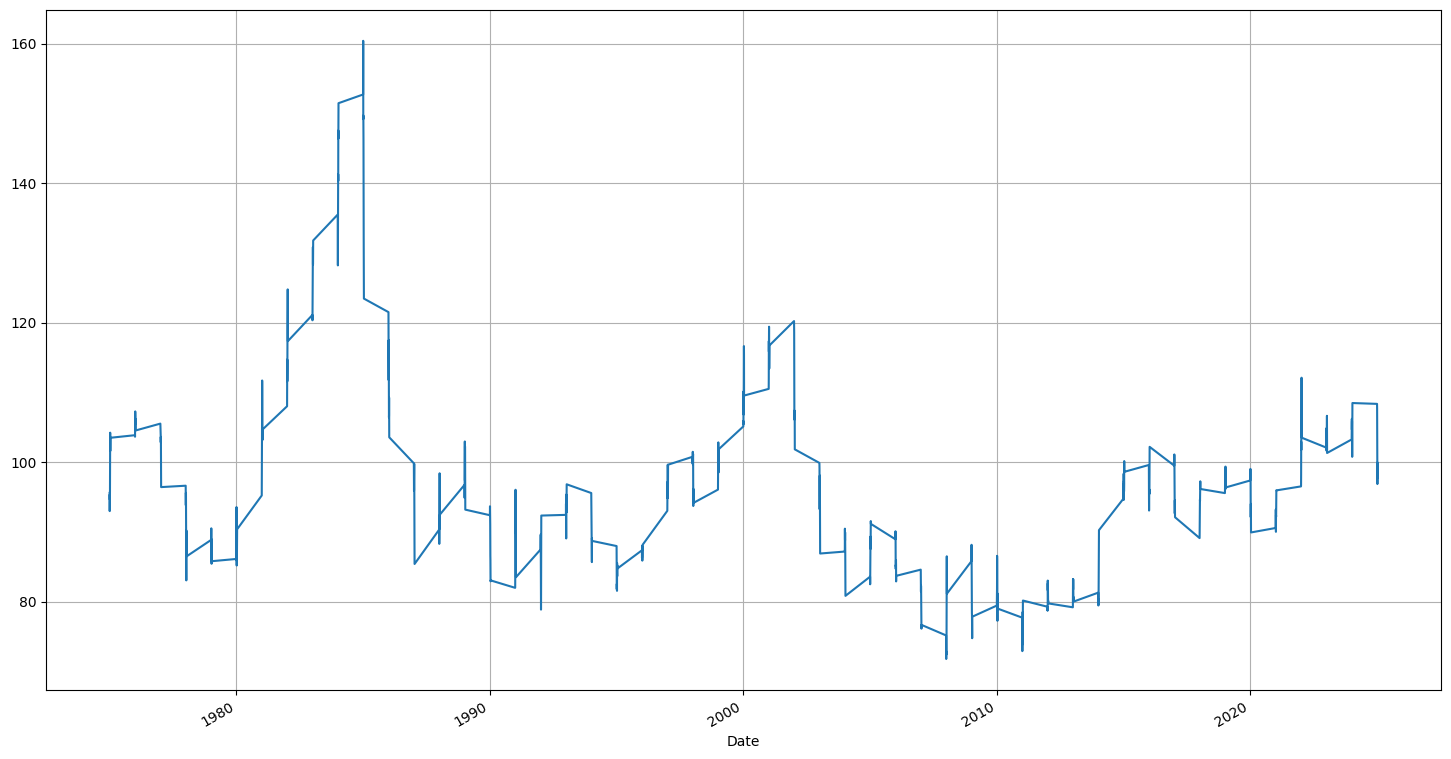

In [42]:
df["DXY"].plot(figsize=(18,10), grid=True)

In [43]:


# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["DXY"].dropna())
print(f"DXY lambda: {lambda_val:.4f}")

DXY lambda: -1.6893


<Axes: xlabel='Date'>

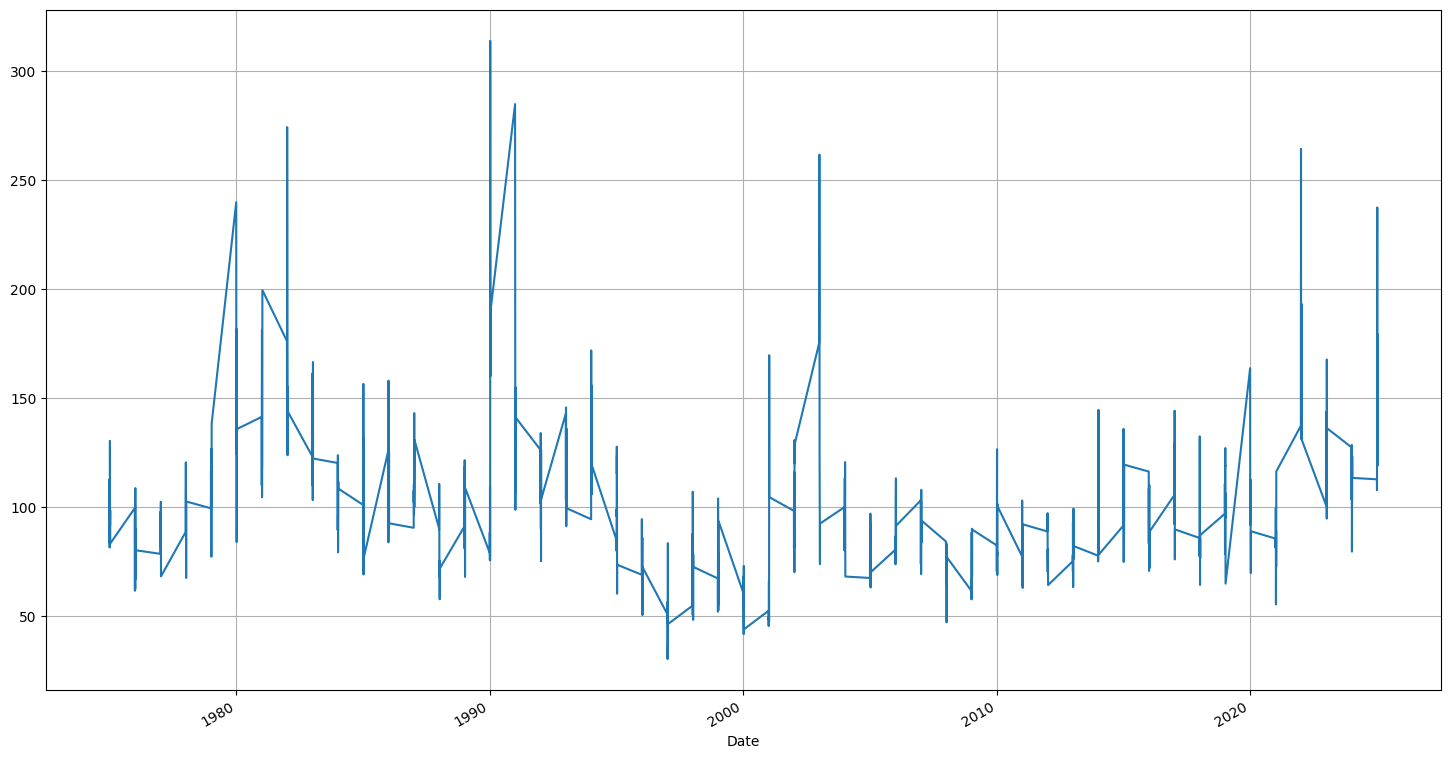

In [44]:
df["GPRHT"].plot(figsize=(18,10), grid=True)

In [45]:
# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["GPRHT"].dropna())
print(f"GPRHT lambda: {lambda_val:.4f}")

GPRHT lambda: -0.1111


<Axes: title={'center': 'GPRHT Log'}, xlabel='Date'>

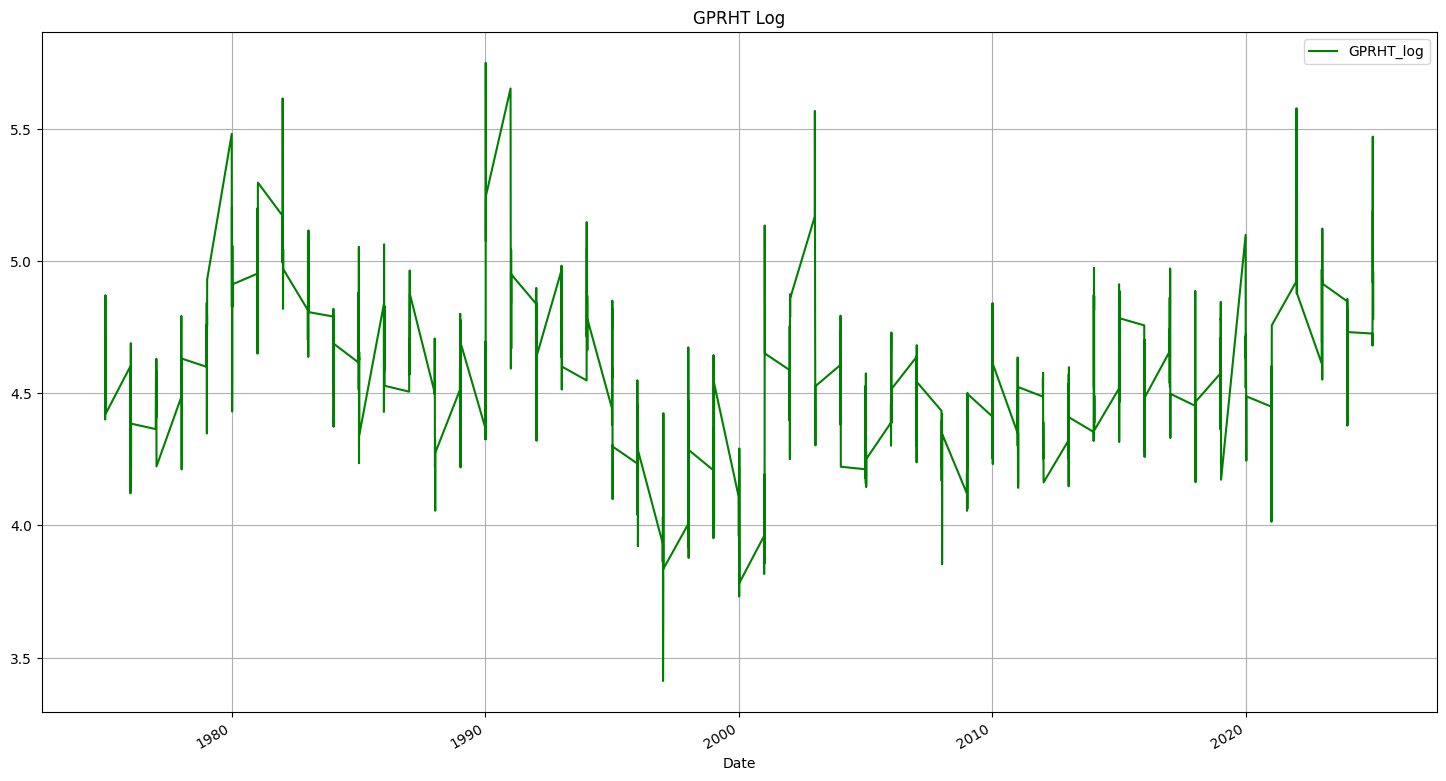

In [46]:
df["GPRHT_log"] = np.log(df["GPRHT"])


df[["GPRHT_log"]].plot(figsize=(18,10), title="GPRHT Log", grid=True, color="green")

<Axes: xlabel='Date'>

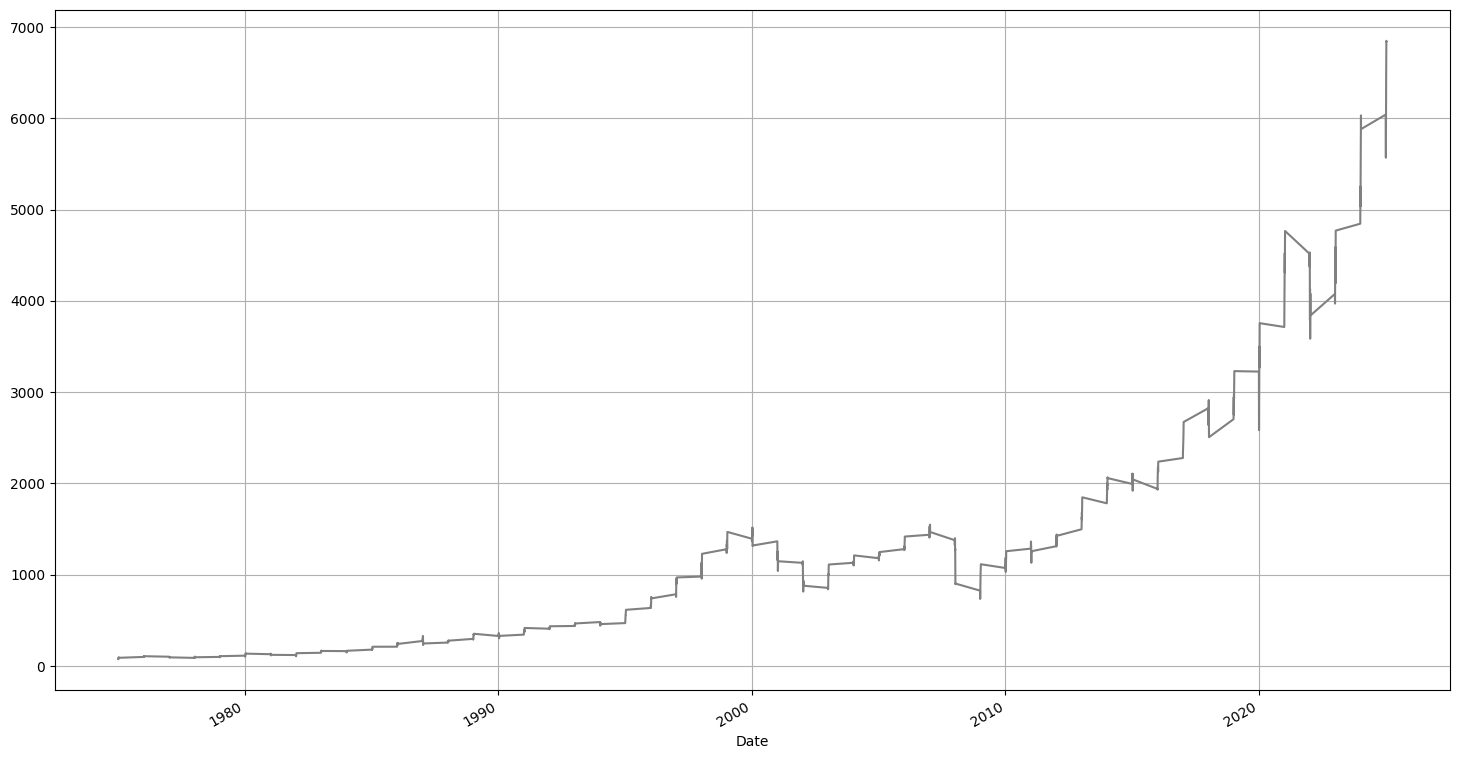

In [47]:
df["SPX500"].plot(figsize=(18,10), grid=True, color="grey")

In [48]:
transformed, lambda_val = stats.boxcox(df["SPX500"].dropna())
print(f"SPX500_lambda: {lambda_val:.4f}")

SPX500_lambda: 0.0972


<Axes: title={'center': 'SPX500 Log'}, xlabel='Date'>

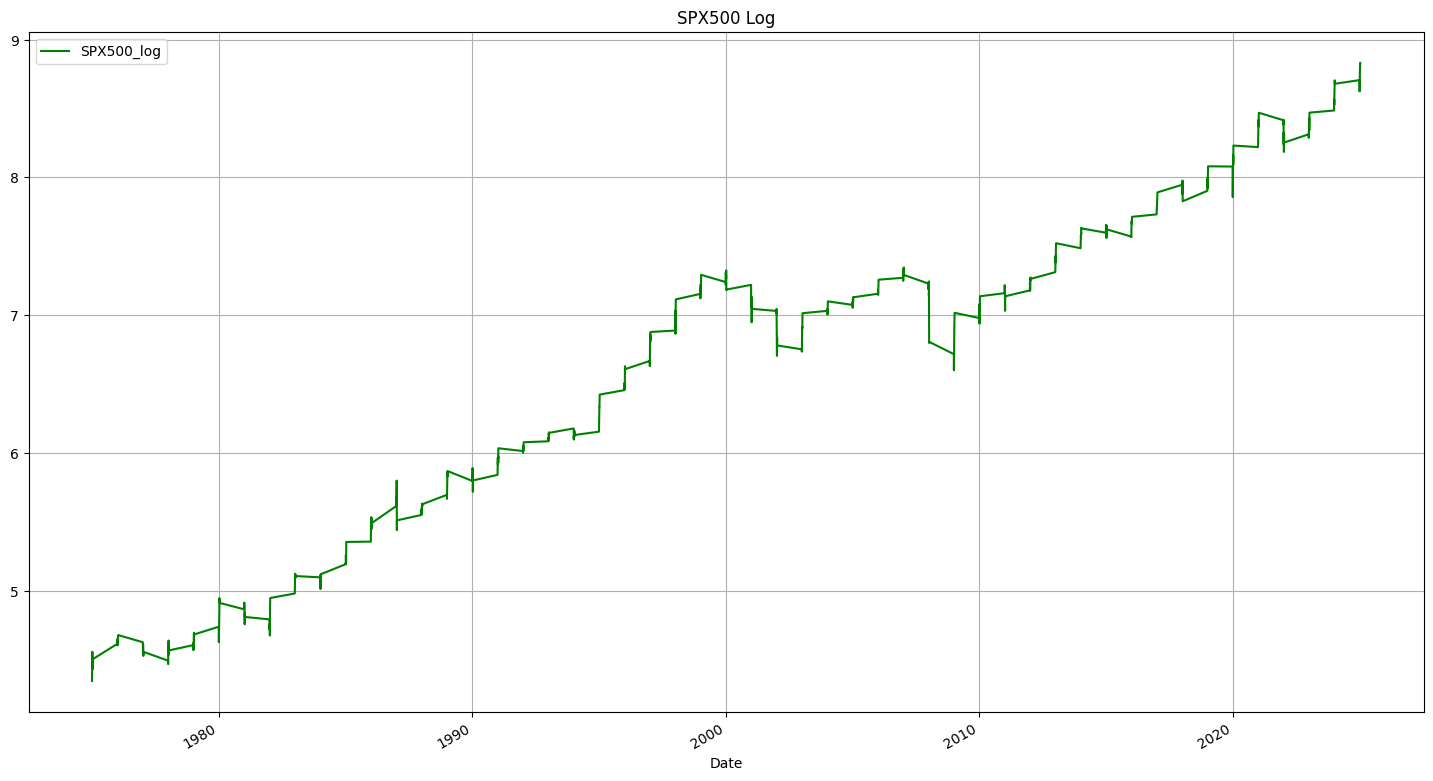

In [49]:
df["SPX500_log"] = np.log(df["SPX500"])


df[["SPX500_log"]].plot(figsize=(18,10), title="SPX500 Log", grid=True, color="green")

In [50]:
#Been Log
#Oil/ GPRHT/ SPX500

In [51]:
df_train = df[df.index.year <= 2024]
df_test  = df[df.index.year == 2025]

In [52]:
# Define exactly which version to use for each variable
cols_to_test = [
    "Silver_Price",      # log version
    "Oil_Price_log",       # log version
    "GPRHT_log",     # log version
    "SPX500_log",    # log version
    "DXY",  
    "Inflation_Changes",# original
    "Interest_Rate", # original
]

for col in cols_to_test:
    result = adfuller(df_train[col].dropna())
    pval = result[1]
    status = "stationary" if pval <= 0.05 else "NON-STATIONARY"
    print(f"{col}: p-value = {pval:.4f} → {status}")

Silver_Price: p-value = 0.6269 → NON-STATIONARY
Oil_Price_log: p-value = 0.2088 → NON-STATIONARY
GPRHT_log: p-value = 0.0000 → stationary
SPX500_log: p-value = 0.8863 → NON-STATIONARY
DXY: p-value = 0.2053 → NON-STATIONARY
Inflation_Changes: p-value = 0.0470 → stationary
Interest_Rate: p-value = 0.6631 → NON-STATIONARY


Silver_Price_d1: p-value = 0.0000 → stationary ✓
Oil_Price_log_d1: p-value = 0.0000 → stationary ✓
SPX500_log_d1: p-value = 0.0000 → stationary ✓
DXY_d1: p-value = 0.0000 → stationary ✓
Interest_Rate_d1: p-value = 0.0000 → stationary ✓
GPRHT_log: p-value = 0.0000 → stationary ✓
Inflation_Changes: p-value = 0.0470 → stationary ✓


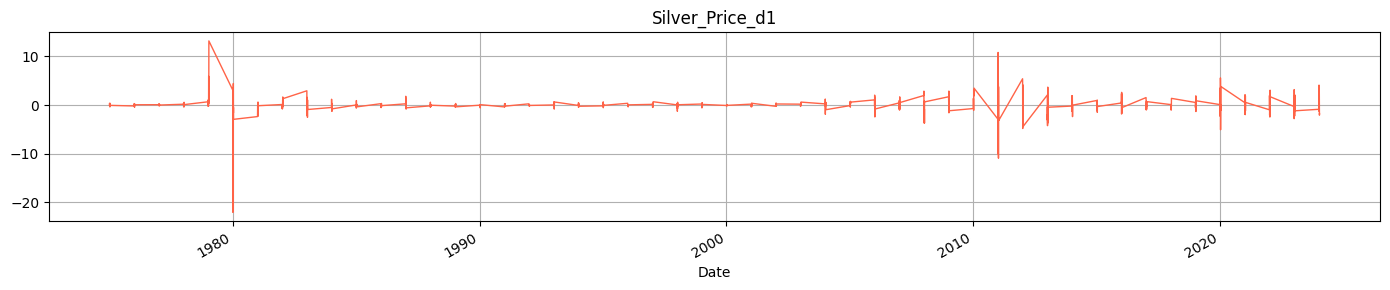

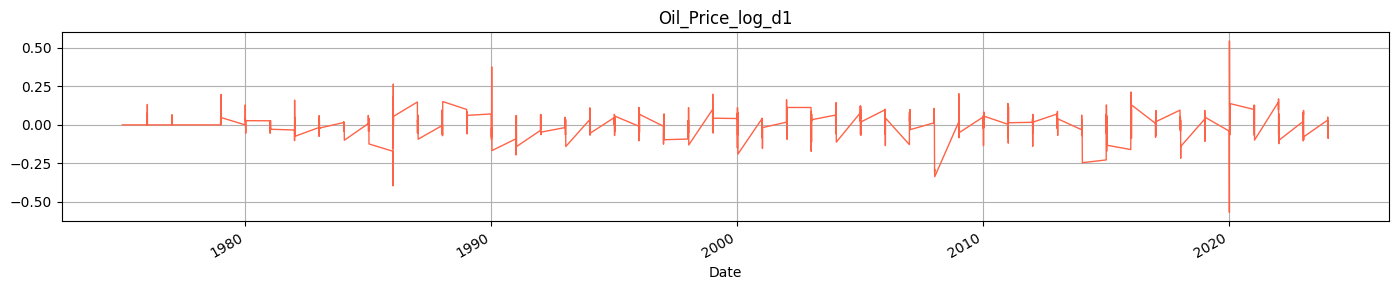

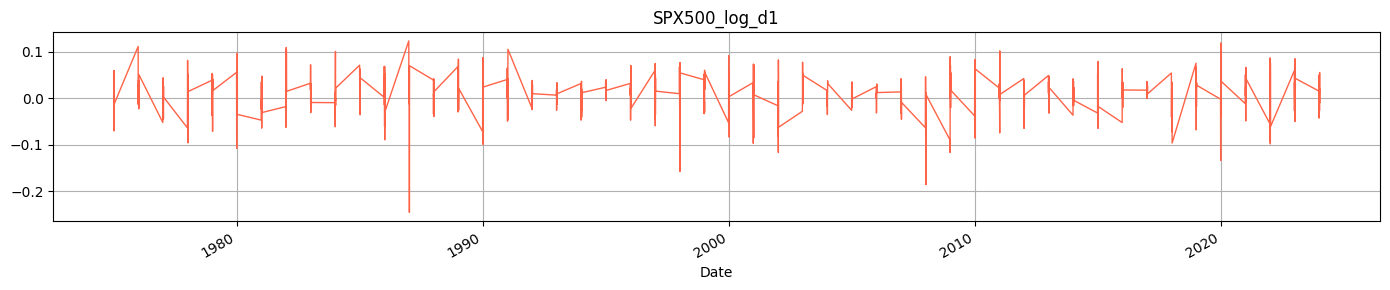

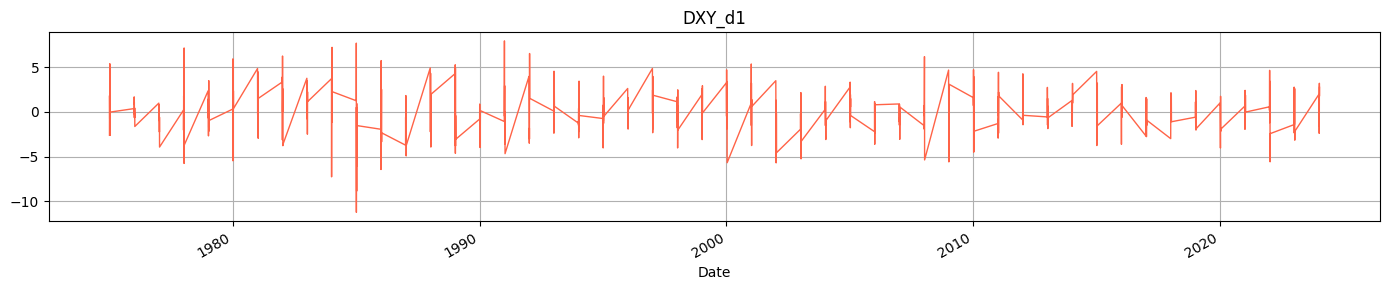

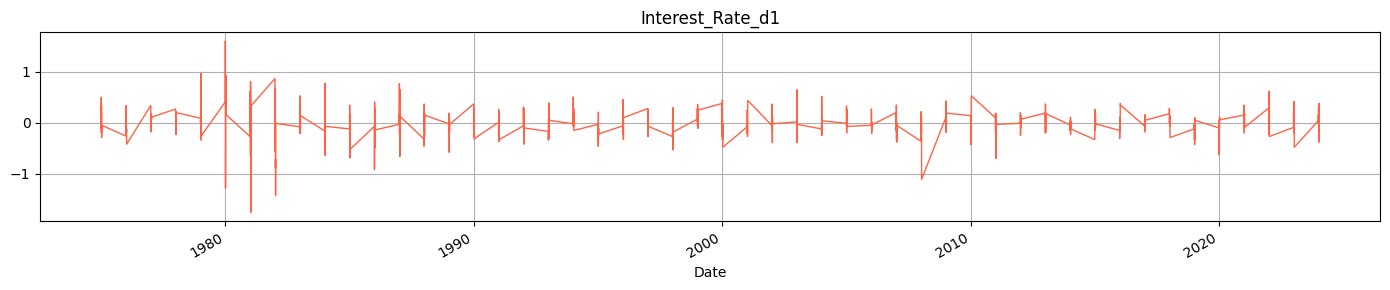

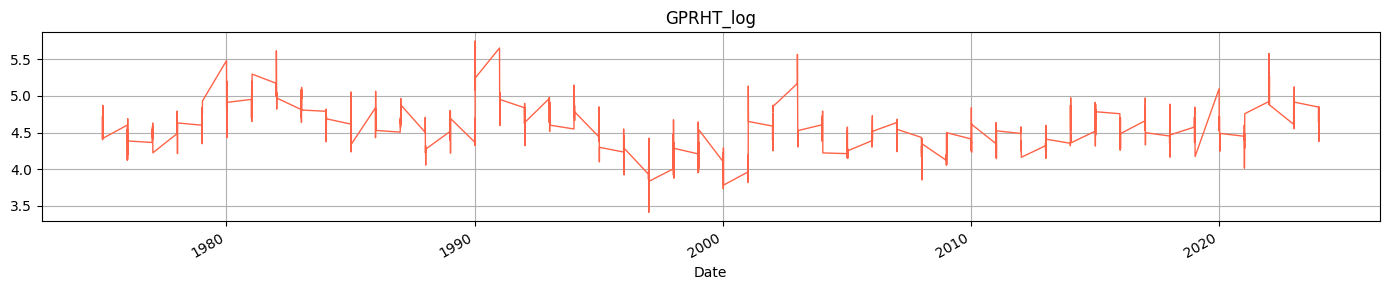

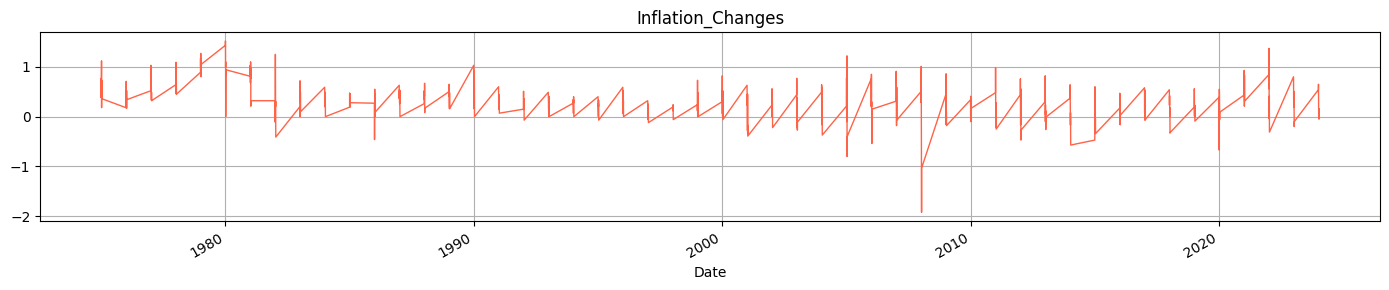

In [53]:
# Apply first difference to non-stationary variables
diff_cols = ["Silver_Price", "Oil_Price_log", "SPX500_log", 
             "DXY", "Interest_Rate"]

for col in diff_cols:
    df_train[col + "_d1"] = df_train[col].diff()

# Re-run ADF on differenced versions
cols_retest = [
    "Silver_Price_d1",
    "Oil_Price_log_d1", 
    "SPX500_log_d1",
    "DXY_d1",
    "Interest_Rate_d1",
    "GPRHT_log",        # already stationary
    "Inflation_Changes" # already stationary
]

for col in cols_retest:
    result = adfuller(df_train[col].dropna())
    pval = result[1]
    status = "stationary ✓" if pval <= 0.05 else "STILL NON-STATIONARY"
    print(f"{col}: p-value = {pval:.4f} → {status}")

    # ── Plot stationary versions only ──────────────────────────────

for col in cols_retest:
    df_train[col].plot(figsize=(14, 3), color="tomato", 
                       linewidth=1, grid=True, title=col)
    plt.tight_layout()
    plt.show()

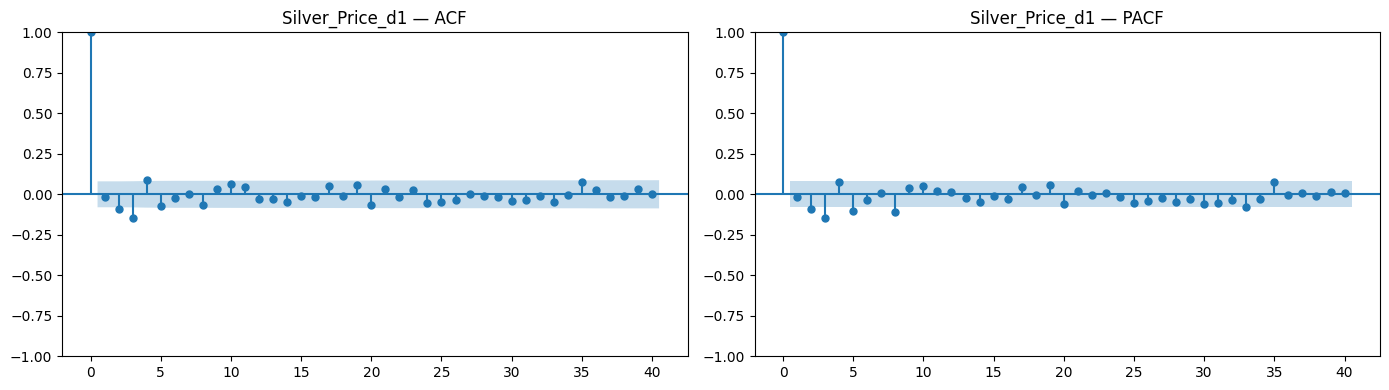

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_train["Silver_Price_d1"].dropna(), lags=40, ax=axes[0])
plot_pacf(df_train["Silver_Price_d1"].dropna(), lags=40, ax=axes[1])

axes[0].set_title("Silver_Price_d1 — ACF")
axes[1].set_title("Silver_Price_d1 — PACF")

plt.tight_layout()
plt.show()


In [55]:
!pip install pmdarima



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from pmdarima import auto_arima

auto_model = auto_arima(
    df_train["Silver_Price_d1"].dropna(),
    d=0,              # already differenced
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  599
Model:               SARIMAX(3, 0, 1)   Log Likelihood               -1197.789
Date:                Sat, 06 Jun 2026   AIC                           2405.578
Time:                        22:52:50   BIC                           2427.555
Sample:                             0   HQIC                          2414.134
                                - 599                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4755      0.074     -6.455      0.000      -0.620      -0.331
ar.L2         -0.0969      0.021     -4.519      0.000      -0.139      -0.055
ar.L3         -0.1943      0.019    -10.320      0.0

In [64]:
# Apply log to X variables only (Silver doesn't need log)
df_test["Oil_Price_log"] = np.log(df_test["Oil_Price"])
df_test["SPX500_log"]    = np.log(df_test["SPX500"])

# Apply differencing to test data
# Must combine with last row of train to get correct first difference
full_data = pd.concat([df_train, df_test])

for col in ["Oil_Price_log", "SPX500_log", "DXY", "Interest_Rate"]:
    full_data[col + "_d1"] = full_data[col].diff()

# Also difference Silver Price
full_data["Silver_Price_d1"] = full_data["Silver_Price"].diff()

# Extract test portion back
df_test = full_data[full_data.index.year == 2025].copy()

In [67]:
# Define exog variables
exog_cols = [
    "Oil_Price_log_d1",
    "SPX500_log_d1",
    "DXY_d1",
    "Interest_Rate_d1",
    "GPRHT_log",
    "Inflation_Changes"
]

# Clean training data
train_silver = df_train[["Silver_Price"] + exog_cols].dropna()

# Build ARIMAX model
model_silver = SARIMAX(
    train_silver["Silver_Price"],
    exog=train_silver[exog_cols],
    order=(3, 1, 1),
    trend='c'
).fit(disp=False)

print(model_silver.summary())

                               SARIMAX Results                                
Dep. Variable:           Silver_Price   No. Observations:                  599
Model:               SARIMAX(3, 1, 1)   Log Likelihood               -1178.702
Date:                Sat, 06 Jun 2026   AIC                           2381.404
Time:                        23:28:21   BIC                           2434.127
Sample:                             0   HQIC                          2401.931
                                - 599                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0762      0.141      0.541      0.589      -0.200       0.352
Oil_Price_log_d1      0.5541      0.839      0.660      0.509      -1.091       2.199
SPX500_log_d1         2.

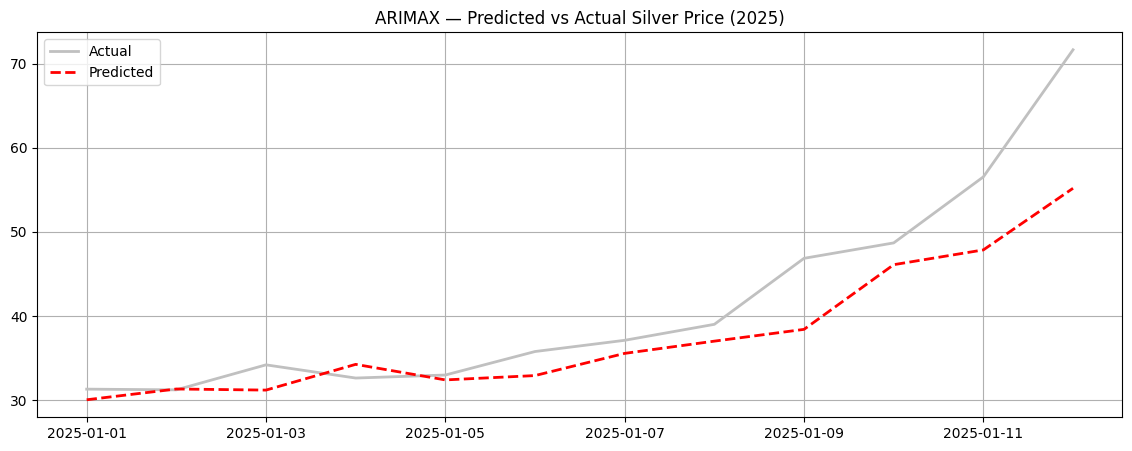

MAE  : 4.10
RMSE : 6.14
MAPE : 8.24%

── Monthly Comparison Table ──
                     Actual  Predicted  Difference  Error (%)
2025-01-01 00:00:00   31.31      30.05        1.26       4.04
2025-01-02 00:00:00   31.23      31.33       -0.10       0.32
2025-01-03 00:00:00   34.20      31.20        3.00       8.77
2025-01-04 00:00:00   32.63      34.26       -1.63       4.99
2025-01-05 00:00:00   32.99      32.41        0.58       1.76
2025-01-06 00:00:00   35.78      32.92        2.86       7.99
2025-01-07 00:00:00   37.12      35.56        1.55       4.19
2025-01-08 00:00:00   39.02      37.02        2.00       5.12
2025-01-09 00:00:00   46.86      38.42        8.44      18.02
2025-01-10 00:00:00   48.69      46.11        2.59       5.32
2025-01-11 00:00:00   56.54      47.86        8.68      15.35
2025-01-12 00:00:00   71.65      55.19       16.46      22.98
AVERAGE                 NaN        NaN         NaN       8.24


In [72]:
# Rolling one-step forecast — all variables
test_silver = df_test[exog_cols].dropna()
predictions = []

for i in range(len(test_silver)):
    endog_temp = pd.concat([
        train_silver["Silver_Price"],
        df_test["Silver_Price"].iloc[:i]
    ])
    exog_temp = pd.concat([
        train_silver[exog_cols],
        test_silver.iloc[:i]
    ])

    temp_model  = SARIMAX(endog_temp, exog=exog_temp, order=(3,1,1), trend='c')
    temp_result = temp_model.filter(model_silver.params)
    pred        = temp_result.forecast(steps=1, exog=test_silver.iloc[[i]])
    predictions.append(pred.iloc[0])

pred_silver   = pd.Series(predictions, index=test_silver.index)
actual_silver = df_test["Silver_Price"].dropna()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(actual_silver.index, actual_silver, 
         label="Actual", color="silver", linewidth=2)
plt.plot(pred_silver.index, pred_silver, 
         label="Predicted", color="red", linestyle="--", linewidth=2)
plt.title("ARIMAX — Predicted vs Actual Silver Price (2025)")
plt.legend()
plt.grid(True)
plt.show()

# Metrics
mae  = mean_absolute_error(actual_silver, pred_silver)
rmse = np.sqrt(mean_squared_error(actual_silver, pred_silver))
mape = np.mean(np.abs((actual_silver - pred_silver) / actual_silver)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# ── Comparison table ──────────────────────────────────────
results_table = pd.DataFrame({
    "Actual"     : actual_silver.values,
    "Predicted"  : pred_silver.values,
    "Difference" : (actual_silver.values - pred_silver.values),
    "Error (%)"  : (abs(actual_silver.values - pred_silver.values) / actual_silver.values * 100)
}, index=actual_silver.index)

results_table = results_table.round(2)

# Add average row at bottom
avg_row = pd.DataFrame({
   
    "Error (%)"  : [round((abs(actual_silver.values - pred_silver.values) / actual_silver.values * 100).mean(), 2)]
}, index=["AVERAGE"])

results_table = pd.concat([results_table, avg_row])

print("\n── Monthly Comparison Table ──")
print(results_table.to_string())

In [73]:
import warnings
warnings.filterwarnings("ignore")

best_aic   = np.inf
best_order = None
results_aic = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = SARIMAX(
                train_silver["Silver_Price"],
                exog=train_silver[exog_cols],
                order=(p, 1, q),
                trend='c'
            ).fit(disp=False)

            results_aic.append({
                "order" : f"({p},1,{q})",
                "AIC"   : round(m.aic, 2),
                "BIC"   : round(m.bic, 2)
            })

            if m.aic < best_aic:
                best_aic   = m.aic
                best_order = (p, 1, q)

        except:
            pass

aic_df = pd.DataFrame(results_aic).sort_values("AIC")
print(aic_df.to_string(index=False))
print(f"\nBest order : ARIMA{best_order}")
print(f"Best AIC   : {best_aic:.2f}")

  order     AIC     BIC
(1,1,3) 2376.19 2428.91
(2,1,3) 2376.62 2433.74
(3,1,3) 2376.64 2438.15
(3,1,2) 2380.38 2437.49
(3,1,1) 2381.40 2434.13
(0,1,3) 2382.26 2430.59
(3,1,0) 2384.55 2432.88
(2,1,1) 2392.16 2440.49
(1,1,2) 2392.77 2441.10
(1,1,1) 2393.80 2437.74
(2,1,2) 2393.84 2446.56
(0,1,2) 2397.17 2441.10
(2,1,0) 2397.54 2441.47
(0,1,0) 2398.36 2433.51
(0,1,1) 2400.10 2439.65
(1,1,0) 2400.15 2439.70

Best order : ARIMA(1, 1, 3)
Best AIC   : 2376.19


In [74]:
# Print p-values from summary
print(model_silver.summary().tables[1])

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0762      0.141      0.541      0.589      -0.200       0.352
Oil_Price_log_d1      0.5541      0.839      0.660      0.509      -1.091       2.199
SPX500_log_d1         2.9848      1.839      1.623      0.105      -0.619       6.589
DXY_d1               -0.0808      0.034     -2.380      0.017      -0.147      -0.014
Interest_Rate_d1      0.5026      0.258      1.949      0.051      -0.003       1.008
GPRHT_log             0.1017      0.377      0.270      0.787      -0.637       0.841
Inflation_Changes     0.5598      0.339      1.651      0.099      -0.105       1.224
ar.L1                -0.4475      0.100     -4.481      0.000      -0.643      -0.252
ar.L2                -0.0993      0.026     -3.802      0.000      -0.150      -0.048
ar.L3                -0.2016      0.027     -7.442    

In [75]:
# Refit with best order (1,1,3)
model_silver_v2 = SARIMAX(
    train_silver["Silver_Price"],
    exog=train_silver[exog_cols],
    order=(1, 1, 3),
    trend='c'
).fit(disp=False)

print(model_silver_v2.summary())

                               SARIMAX Results                                
Dep. Variable:           Silver_Price   No. Observations:                  599
Model:               SARIMAX(1, 1, 3)   Log Likelihood               -1176.094
Date:                Sat, 06 Jun 2026   AIC                           2376.187
Time:                        23:38:53   BIC                           2428.911
Sample:                             0   HQIC                          2396.715
                                - 599                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0638      0.113      0.567      0.571      -0.157       0.284
Oil_Price_log_d1      0.5292      0.820      0.646      0.518      -1.077       2.135
SPX500_log_d1         2.

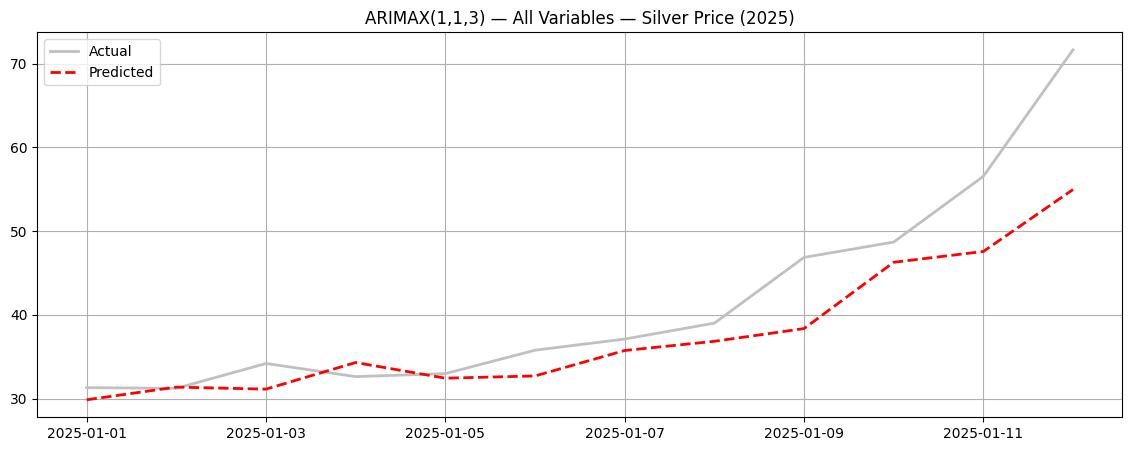

MAE  : 4.17
RMSE : 6.24
MAPE : 8.41%

── Monthly Comparison Table ──
                     Actual  Predicted  Difference  Error (%)
2025-01-01 00:00:00   31.31      29.87        1.45       4.62
2025-01-02 00:00:00   31.23      31.38       -0.15       0.49
2025-01-03 00:00:00   34.20      31.14        3.06       8.96
2025-01-04 00:00:00   32.63      34.32       -1.68       5.16
2025-01-05 00:00:00   32.99      32.44        0.55       1.65
2025-01-06 00:00:00   35.78      32.71        3.07       8.59
2025-01-07 00:00:00   37.12      35.75        1.37       3.69
2025-01-08 00:00:00   39.02      36.85        2.17       5.56
2025-01-09 00:00:00   46.86      38.36        8.50      18.13
2025-01-10 00:00:00   48.69      46.28        2.42       4.96
2025-01-11 00:00:00   56.54      47.57        8.97      15.87
2025-01-12 00:00:00   71.65      54.97       16.68      23.28
AVERAGE               41.50      37.64        3.87       8.41


In [76]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Rolling forecast — all variables, order (1,1,3)
test_silver = df_test[exog_cols].dropna()
predictions = []

for i in range(len(test_silver)):
    endog_temp = pd.concat([
        train_silver["Silver_Price"],
        df_test["Silver_Price"].iloc[:i]
    ])
    exog_temp = pd.concat([
        train_silver[exog_cols],
        test_silver.iloc[:i]
    ])

    temp_model  = SARIMAX(endog_temp, exog=exog_temp, order=(1,1,3), trend='c')
    temp_result = temp_model.filter(model_silver_v2.params)
    pred        = temp_result.forecast(steps=1, exog=test_silver.iloc[[i]])
    predictions.append(pred.iloc[0])

pred_silver   = pd.Series(predictions, index=test_silver.index)
actual_silver = df_test["Silver_Price"].dropna()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(actual_silver.index, actual_silver,
         label="Actual", color="silver", linewidth=2)
plt.plot(pred_silver.index, pred_silver,
         label="Predicted", color="red", linestyle="--", linewidth=2)
plt.title("ARIMAX(1,1,3) — All Variables — Silver Price (2025)")
plt.legend()
plt.grid(True)
plt.show()

# Metrics
mae  = mean_absolute_error(actual_silver, pred_silver)
rmse = np.sqrt(mean_squared_error(actual_silver, pred_silver))
mape = np.mean(np.abs((actual_silver - pred_silver) / actual_silver)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Comparison table
results_table = pd.DataFrame({
    "Actual"     : actual_silver.values,
    "Predicted"  : pred_silver.values,
    "Difference" : (actual_silver.values - pred_silver.values),
    "Error (%)"  : (abs(actual_silver.values - pred_silver.values) / actual_silver.values * 100)
}, index=actual_silver.index).round(2)

avg_row = pd.DataFrame({
    "Actual"     : [round(actual_silver.mean(), 2)],
    "Predicted"  : [round(pred_silver.mean(), 2)],
    "Difference" : [round((actual_silver.values - pred_silver.values).mean(), 2)],
    "Error (%)"  : [round(mape, 2)]
}, index=["AVERAGE"])

results_table = pd.concat([results_table, avg_row])
print("\n── Monthly Comparison Table ──")
print(results_table.to_string())

In [77]:
# Keep only significant X variables
exog_cols_silver = ["DXY_d1", "Interest_Rate_d1"]

train_silver2 = df_train[["Silver_Price"] + exog_cols_silver].dropna()

model_silver3 = SARIMAX(
    train_silver2["Silver_Price"],
    exog=train_silver2[exog_cols_silver],
    order=(1, 1, 3),
    trend='c'
).fit(disp=False)

print(f"All variables AIC : 2376.19")
print(f"Filtered AIC      : {model_silver3.aic:.2f}")

All variables AIC : 2376.19
Filtered AIC      : 2381.56


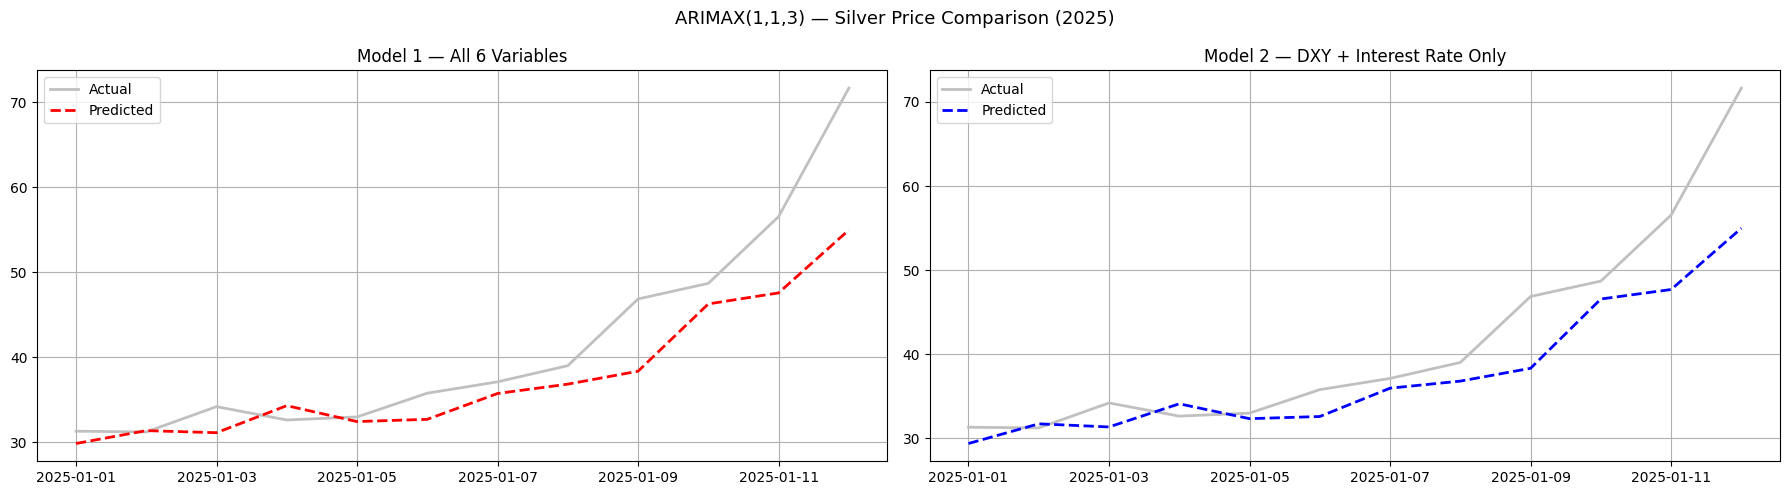

Metric      All Variables    DXY+Interest Rate
----------------------------------------------
MAE                  4.17                 4.18
RMSE                 6.24                 6.22
MAPE                8.41%                8.49%

── Model 1 — All Variables ──
                     Actual  Predicted  Difference  Error (%)
2025-01-01 00:00:00   31.31      29.87        1.45       4.62
2025-01-02 00:00:00   31.23      31.38       -0.15       0.49
2025-01-03 00:00:00   34.20      31.14        3.06       8.96
2025-01-04 00:00:00   32.63      34.32       -1.68       5.16
2025-01-05 00:00:00   32.99      32.44        0.55       1.65
2025-01-06 00:00:00   35.78      32.71        3.07       8.59
2025-01-07 00:00:00   37.12      35.75        1.37       3.69
2025-01-08 00:00:00   39.02      36.85        2.17       5.56
2025-01-09 00:00:00   46.86      38.36        8.50      18.13
2025-01-10 00:00:00   48.69      46.28        2.42       4.96
2025-01-11 00:00:00   56.54      47.57        8.97  

In [79]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Define variables ────────────────────────────────────────────
exog_all = [
    "Oil_Price_log_d1", "SPX500_log_d1", "DXY_d1",
    "Interest_Rate_d1", "GPRHT_log", "Inflation_Changes"
]
exog_sig = ["DXY_d1", "Interest_Rate_d1"]

# ── Training data ───────────────────────────────────────────────
train_all = df_train[["Silver_Price"] + exog_all].dropna()
train_sig = df_train[["Silver_Price"] + exog_sig].dropna()

# ── Fit both models ─────────────────────────────────────────────
model_all = SARIMAX(train_all["Silver_Price"], exog=train_all[exog_all],
                    order=(1,1,3), trend='c').fit(disp=False)

model_sig = SARIMAX(train_sig["Silver_Price"], exog=train_sig[exog_sig],
                    order=(1,1,3), trend='c').fit(disp=False)

# ── Rolling forecast — all variables ───────────────────────────
test_all  = df_test[exog_all].dropna()
preds_all = []

for i in range(len(test_all)):
    endog_temp = pd.concat([train_all["Silver_Price"], df_test["Silver_Price"].iloc[:i]])
    exog_temp  = pd.concat([train_all[exog_all], test_all.iloc[:i]])
    tmp        = SARIMAX(endog_temp, exog=exog_temp, order=(1,1,3), trend='c')
    preds_all.append(tmp.filter(model_all.params).forecast(steps=1, exog=test_all.iloc[[i]]).iloc[0])

# ── Rolling forecast — significant variables ────────────────────
test_sig  = df_test[exog_sig].dropna()
preds_sig = []

for i in range(len(test_sig)):
    endog_temp = pd.concat([train_sig["Silver_Price"], df_test["Silver_Price"].iloc[:i]])
    exog_temp  = pd.concat([train_sig[exog_sig], test_sig.iloc[:i]])
    tmp        = SARIMAX(endog_temp, exog=exog_temp, order=(1,1,3), trend='c')
    preds_sig.append(tmp.filter(model_sig.params).forecast(steps=1, exog=test_sig.iloc[[i]]).iloc[0])

pred_all    = pd.Series(preds_all, index=test_all.index)
pred_sig    = pd.Series(preds_sig, index=test_sig.index)
actual_silv = df_test["Silver_Price"].dropna()

# ── Side by side charts ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(actual_silv.index, actual_silv, label="Actual", color="silver", linewidth=2)
axes[0].plot(pred_all.index, pred_all, label="Predicted", color="red", linestyle="--", linewidth=2)
axes[0].set_title("Model 1 — All 6 Variables")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(actual_silv.index, actual_silv, label="Actual", color="silver", linewidth=2)
axes[1].plot(pred_sig.index, pred_sig, label="Predicted", color="blue", linestyle="--", linewidth=2)
axes[1].set_title("Model 2 — DXY + Interest Rate Only")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ARIMAX(1,1,3) — Silver Price Comparison (2025)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Metrics ─────────────────────────────────────────────────────
mae_all  = mean_absolute_error(actual_silv, pred_all)
rmse_all = np.sqrt(mean_squared_error(actual_silv, pred_all))
mape_all = np.mean(np.abs((actual_silv - pred_all) / actual_silv)) * 100

mae_sig  = mean_absolute_error(actual_silv, pred_sig)
rmse_sig = np.sqrt(mean_squared_error(actual_silv, pred_sig))
mape_sig = np.mean(np.abs((actual_silv - pred_sig) / actual_silv)) * 100

print(f"{'Metric':<8} {'All Variables':>16} {'DXY+Interest Rate':>20}")
print("-" * 46)
print(f"{'MAE':<8} {mae_all:>16.2f} {mae_sig:>20.2f}")
print(f"{'RMSE':<8} {rmse_all:>16.2f} {rmse_sig:>20.2f}")
print(f"{'MAPE':<8} {mape_all:>15.2f}% {mape_sig:>19.2f}%")

# ── Comparison tables ───────────────────────────────────────────
def make_table(actual, predicted, label):
    tbl = pd.DataFrame({
        "Actual"     : actual.values,
        "Predicted"  : predicted.values,
        "Difference" : (actual.values - predicted.values),
        "Error (%)"  : (abs(actual.values - predicted.values) / actual.values * 100)
    }, index=actual.index).round(2)

    avg = pd.DataFrame({
        "Actual"     : [round(actual.mean(), 2)],
        "Predicted"  : [round(predicted.mean(), 2)],
        "Difference" : [round((actual.values - predicted.values).mean(), 2)],
        "Error (%)"  : [round(mape_all if label == "All" else mape_sig, 2)]
    }, index=["AVERAGE"])

    print(f"\n── {label} ──")
    print(pd.concat([tbl, avg]).to_string())

make_table(actual_silv, pred_all, "Model 1 — All Variables")
make_table(actual_silv, pred_sig, "Model 2 — DXY + Interest Rate")